# 4. Network Edge Inference and Topology

Notebook 3 (v3) already runs the ROLS pipeline and saves the local connectivity matrix `A_rols`, the global response matrix `G_rols`, and the z-score edge list from the cosine cross-perturbation matrix (`edges_zscore_stim_*`). This notebook builds on those outputs:

**Consensus edges:** For each gene pair (i, j), an edge is called if it passes both the Z-score threshold (Notebook 3 z-score edges) AND has |A_rols[i,j]| above a strength percentile threshold (computed per condition). Requiring both methods to agree substantially reduces false positives.

**ROLS only:** this notebook uses ROLS as the sole network-inference method. Notebook 3 found ROLS and pseudobulk BMRA to disagree substantially (see Section 4 markdown for details); pseudobulk is not used as a second confirmation source here.

**Single axis:** ROLS produces one A/G matrix per condition (one transcriptome). For Stim8hr (where `SKIP_BTLA=False`), both stim and BTLA z-score edge lists exist from Notebook 3 and are each intersected separately with the same `A_rols`-derived strength edges. For Rest and Stim48hr (`SKIP_BTLA=True`), only the stim axis is processed.

## Contents
1. Configuration
2. Load inputs
3. Strength-threshold edges from A_rols
4. Consensus edges (vs Notebook 3 z-score edges)
5. Node attribute table
6. Network summary
7. KEGG TCR pathway comparison (hsa04660)
8. STRING/TRRUST external validation
9. Recap
10. Save


### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


In [2]:
# Must match Notebooks 1, 2, 3
CONDITION = 'Stim48hr' # 'Rest' | 'Stim8hr' | 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# BTLA: skip at Rest and Stim48hr, matches Notebook 3
SKIP_BTLA = (CONDITION == 'Stim48hr' or CONDITION == 'Rest')

# ROLS outputs from Notebook 3
INFERENCE_PATH = 'rols'

COND_DIR = f'../Results/{CONDITION}'
IN_DIR = os.path.join(COND_DIR, INFERENCE_PATH)
OUT_DIR = IN_DIR
DATA_DIR = '../Data'

# Edge inference parameters
# Percentile threshold on |A_rols| off-diagonal, computed per condition (Section 2) instead of
# a fixed value, since A_rols/G_rols range varies substantially across conditions (see Notebook 3
# summary tables: G_rols range was [-24, 18] at Rest, [-67, 51] at Stim8hr, [-5, 6] at Stim48hr).
STRENGTH_PERCENTILE = 95 # top 5% by |A_rols| off-diagonal

# KEGG reference pathway for biological interpretation (Section 7)
KEGG_PATHWAY_FILE = os.path.join(DATA_DIR, 'hsa04660.xml')
KEGG_PATHWAY_ID = 'hsa04660'
KEGG_PATHWAY_NAME = 'T cell receptor signaling pathway'

print(f'run_tag: {run_tag}')
print(f'SKIP_BTLA: {SKIP_BTLA}')
print(f'Inference path: {INFERENCE_PATH}')
print(f'In dir: {IN_DIR}')
print(f'Strength percentile threshold: top {100 - STRENGTH_PERCENTILE}%')

# STRING / TRRUST external validation (Section 8)
DATA_DIR_VAL = '../Data'
STRING_LINKS_FILE = os.path.join(DATA_DIR_VAL, '9606.protein.links.v12.0.txt.gz')
STRING_INFO_FILE = os.path.join(DATA_DIR_VAL, '9606.protein.info.v12.0.txt.gz')
TRRUST_FILE = os.path.join(DATA_DIR_VAL, 'trrust_rawdata.human.tsv')
STRING_SCORE_HIGH = 700 # high confidence combined_score
STRING_SCORE_MED = 400 # medium confidence combined_score
# Sweep tested independently of the main STRENGTH_PERCENTILE above; does not affect
# final_stim/final_btla/node_df, which stay fixed at STRENGTH_PERCENTILE for consistency
# with Notebooks 3 and 5.
STRENGTH_PERCENTILE_SWEEP = [80, 90, 95, 99]

# Checkpoint genes: biological focus of this project, reported separately throughout
CHECKPOINT_GENES = ['PTPN11', 'PTPN6', 'PDCD1', 'BTLA']


run_tag: Stim48hr_D1_D2_D3_D4
SKIP_BTLA: True
Inference path: rols
In dir: ../Results/Stim48hr/rols
Strength percentile threshold: top 5%


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import hypergeom
import xml.etree.ElementTree as ET
print('Packages loaded.')


Packages loaded.


### 2. Load Inputs

In [4]:
core_df = pd.read_csv(os.path.join(COND_DIR, f'core_genes_{run_tag}.csv'))
core_genes = core_df['target_contrast_gene_name'].tolist()
N = len(core_genes)
gene_to_idx = {g: i for i, g in enumerate(core_genes)}

dpd_stim = core_df.set_index('target_contrast_gene_name')['DPD_stim_norm'].reindex(core_genes).values
dpd_btla = core_df.set_index('target_contrast_gene_name')['DPD_btla_norm'].reindex(core_genes).values
n_sig = core_df.set_index('target_contrast_gene_name')['n_sig_genes'].reindex(core_genes).values

print(f'Core genes: {N}')
print(f'DPD_stim range: [{dpd_stim.min():.3f}, {dpd_stim.max():.3f}]')
print(f'DPD_btla range: [{dpd_btla.min():.3f}, {dpd_btla.max():.3f}]')


Core genes: 200
DPD_stim range: [-23.398, 2.485]
DPD_btla range: [-2.049, 1.531]


In [5]:
# A and G matrices from Notebook 3 (ROLS)
A_rols_raw = pd.read_csv(os.path.join(IN_DIR, f'A_local_rols_{run_tag}.csv'), index_col=0)
G_rols_raw = pd.read_csv(os.path.join(IN_DIR, f'G_global_rols_{run_tag}.csv'), index_col=0)

# Sanity check BEFORE reindexing: core_genes (Notebook 1/2, 200 genes) and the A_rols/G_rols
# index (perturbed_gene_list, Notebook 3/Sonic, 196 genes here) can differ. A handful of genes
# present in core_genes_{run_tag}.csv may not have made it into the single-cell ROLS input on
# Sonic (script_A_prep.py) -- e.g. dropped during Ensembl-to-symbol mapping or an upstream
# core-genes filter applied at a different point in the pipeline. Rather than guessing at name
# aliases, missing genes are excluded from this notebook's analysis and reported explicitly, since
# forcing a mapping without confirming the cause on Sonic could silently mix up two different genes.
a_rols_genes_set = set(A_rols_raw.index)
core_genes_set = set(core_genes)
missing_from_a_rols = sorted(core_genes_set - a_rols_genes_set)
extra_in_a_rols = sorted(a_rols_genes_set - core_genes_set)

print(f'core_genes (Notebook 1/2): {len(core_genes)}')
print(f'A_rols/G_rols index (Notebook 3, Sonic): {len(A_rols_raw.index)}')

if missing_from_a_rols:
    print(f'\n{len(missing_from_a_rols)} core_genes excluded from this notebook (not in A_rols/G_rols '
          f'index, cause not yet confirmed on Sonic -- see Notebook 3 script_A_prep.py): {missing_from_a_rols}')
if extra_in_a_rols:
    print(f'\nNote: {len(extra_in_a_rols)} genes in A_rols index but not in core_genes (also excluded): {extra_in_a_rols}')

# Restrict core_genes to the intersection, preserving original order
core_genes = [g for g in core_genes if g in a_rols_genes_set]
N = len(core_genes)
# Recompute DPD arrays and gene_to_idx against the restricted core_genes list
dpd_stim = core_df.set_index('target_contrast_gene_name')['DPD_stim_norm'].reindex(core_genes).values
dpd_btla = core_df.set_index('target_contrast_gene_name')['DPD_btla_norm'].reindex(core_genes).values
n_sig = core_df.set_index('target_contrast_gene_name')['n_sig_genes'].reindex(core_genes).values
gene_to_idx = {g: i for i, g in enumerate(core_genes)}

print(f'\ncore_genes restricted to {N} genes present in A_rols/G_rols (analysis proceeds on this set).')

A_rols = A_rols_raw.reindex(index=core_genes, columns=core_genes).values.astype(np.float64)
G_rols = G_rols_raw.reindex(index=core_genes, columns=core_genes).values.astype(np.float64)

print(f'A_rols range: [{A_rols.min():.4f}, {A_rols.max():.4f}]')
print(f'G_rols range: [{G_rols.min():.4f}, {G_rols.max():.4f}]')

# Sanity check: confirm this is the post-fix G_rols from Notebook 3 (G_not applied,
# i.e. diagonal forced to zero). If this prints nonzero, re-run Notebook 3 before continuing.
g_diag_max_abs = np.abs(np.diag(G_rols)).max()
print(f'G_rols diagonal max abs (should be 0.0, confirms G_not applied): {g_diag_max_abs:.6f}')
if g_diag_max_abs > 1e-9:
    print('WARNING: G_rols diagonal is not zero. This G_rols may predate the G_not fix in Notebook 3.')

off_diag = np.abs(A_rols[~np.eye(N, dtype=bool)])
print(f'|A_rols| off-diagonal: min={off_diag.min():.4f}, median={np.median(off_diag):.4f}, max={off_diag.max():.4f}')

# Percentile-based threshold, computed from this condition's A_rols distribution
STRENGTH_THRESHOLD = np.percentile(off_diag, STRENGTH_PERCENTILE)
print(f'Strength threshold (top {100 - STRENGTH_PERCENTILE}% percentile, this condition): {STRENGTH_THRESHOLD:.4f}')
print(f'Genes with |A_rols off-diag| > threshold: {(off_diag > STRENGTH_THRESHOLD).sum()}')


core_genes (Notebook 1/2): 200
A_rols/G_rols index (Notebook 3, Sonic): 197

3 core_genes excluded from this notebook (not in A_rols/G_rols index, cause not yet confirmed on Sonic -- see Notebook 3 script_A_prep.py): ['CEP43', 'H2AZ1', 'SKIC8']

core_genes restricted to 197 genes present in A_rols/G_rols (analysis proceeds on this set).
A_rols range: [-0.3399, 0.4973]
G_rols range: [-1.1989, 3.6244]
G_rols diagonal max abs (should be 0.0, confirms G_not applied): 0.000000
|A_rols| off-diagonal: min=0.0000, median=0.0198, max=0.4973
Strength threshold (top 5% percentile, this condition): 0.0788
Genes with |A_rols off-diag| > threshold: 1931


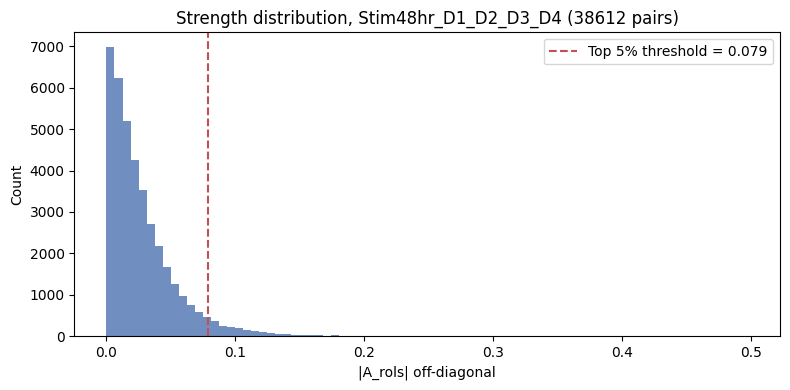

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(off_diag, bins=80, color='#4C72B0', alpha=0.8)
ax.axvline(STRENGTH_THRESHOLD, color='#C44E52', linestyle='--', linewidth=1.5,
           label=f'Top {100 - STRENGTH_PERCENTILE}% threshold = {STRENGTH_THRESHOLD:.3f}')
ax.set_xlabel('|A_rols| off-diagonal')
ax.set_ylabel('Count')
ax.set_title(f'Strength distribution, {run_tag} ({off_diag.size} pairs)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'strength_threshold_{run_tag}.png'), dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Z-score edges from Notebook 3 (already computed there from the cosine cross-perturbation matrix)
edges_z_stim_path = os.path.join(IN_DIR, f'edges_zscore_stim_{run_tag}.csv')
if os.path.exists(edges_z_stim_path):
    edges_z_stim = pd.read_csv(edges_z_stim_path)
else:
    edges_z_stim = pd.DataFrame()
print(f'stim z-score edges: {len(edges_z_stim)}')

if not SKIP_BTLA:
    edges_z_btla_path = os.path.join(IN_DIR, f'edges_zscore_btla_{run_tag}.csv')
    if os.path.exists(edges_z_btla_path):
        edges_z_btla = pd.read_csv(edges_z_btla_path)
    else:
        edges_z_btla = pd.DataFrame()
    print(f'btla z-score edges: {len(edges_z_btla)}')
else:
    edges_z_btla = pd.DataFrame()
    print('SKIP_BTLA=True: btla z-score edges not loaded.')


stim z-score edges: 762
SKIP_BTLA=True: btla z-score edges not loaded.


### 3. Strength-Threshold Edges from A_rols

Calls an edge i -> j if `|A_rols[i,j]|` exceeds the percentile threshold computed in Section 2 (top `100 - STRENGTH_PERCENTILE`% by absolute strength, computed per condition since the A_rols/G_rols range varies substantially across conditions). `A_rols` is the local connectivity matrix produced by `run_chunked_mra`/`run_jax_mra` in Notebook 3 (single-cell ROLS). One A matrix covers both axes; the same `edges_strength_rols` list is intersected with both the stim and (if available) BTLA z-score edge lists in Section 4.

Note: this is distinct from the pseudobulk BMRA in Notebook 3 (which operates on `A_pseudo`, derived from `R/diag(R)`). See Section 4 markdown for why pseudobulk is not used here.


In [8]:
def strength_edges_from_A(A_matrix, gene_list, strength_threshold, dpd_src, dpd_tgt, G_matrix, label):
    # Note: this is NOT the pseudobulk BMRA from Notebook 3 (which thresholds A_pseudo, derived
    # from R/diag(R)). This thresholds A_rols (single-cell ROLS local connectivity) by strength
    # percentile. Naming kept distinct (strength_edges, not edges_bmra) to avoid confusion with
    # the genuinely different pseudobulk BMRA method.
    records = []
    for i, src_gene in enumerate(gene_list):
        for j, tgt_gene in enumerate(gene_list):
            if i == j:
                continue
            if abs(A_matrix[i, j]) > strength_threshold:
                records.append({
                    'source': src_gene, 'target': tgt_gene,
                    'rols_strength': round(float(A_matrix[i, j]), 5),
                    'global_effect': round(float(G_matrix[i, j]), 5),
                    'edge_type': 'activation' if A_matrix[i, j] > 0 else 'inhibition',
                    'source_DPD': round(float(dpd_src[i]), 4),
                    'target_DPD': round(float(dpd_tgt[j]), 4)})
    edges = pd.DataFrame(records)
    if not edges.empty:
        edges = edges.reindex(
            edges['rols_strength'].abs().sort_values(ascending=False).index
        ).reset_index(drop=True)
    print(f'{label}: {len(edges)} strength-threshold edges')
    return edges

edges_strength_rols = strength_edges_from_A(
    A_rols, core_genes, STRENGTH_THRESHOLD, dpd_stim, dpd_stim, G_rols, 'A_rols strength')


A_rols strength: 1931 strength-threshold edges


### 4. Consensus Edges

Intersect each Z-score edge list (stim, and BTLA if available) from Notebook 3 with `edges_strength_rols` from Section 3 (ROLS local connectivity thresholded by strength percentile). An edge is in the consensus only if both methods flag it.

- Z-score can flag spurious edges from broad co-variation in expression profiles
- The strength criterion can include edges near the threshold from numerical noise in the matrix inversion

If one method returns no edges, the fallback is the Z-score list alone, clearly labelled.

**Note on pseudobulk:** this notebook uses ROLS only as the primary network for interpretation. Notebook 3 found ROLS and pseudobulk BMRA to disagree substantially (Pearson r on G values: 0.007-0.134 across conditions; Spearman rank correlation on hub degree: negative or non-significant in all conditions). The two methods are not currently comparable, likely due to a normalization mismatch between ROLS row-wise regression and the pseudobulk R/diag(R) scaling (still unresolved, see Notebook 3 notes). ROLS is used here as the single-cell-native method; pseudobulk is not used as a second confirmation source until this is resolved.


In [9]:
def build_consensus(edges_z, edges_strength, axis_label):
    if edges_z.empty and edges_strength.empty:
        print(f'{axis_label}: no edges from either method.')
        return pd.DataFrame()

    if not edges_z.empty and not edges_strength.empty:
        z_pairs = set(zip(edges_z['source'], edges_z['target']))
        s_pairs = set(zip(edges_strength['source'], edges_strength['target']))
        shared = z_pairs & s_pairs
        print(f'{axis_label}: z-score={len(z_pairs)}, strength={len(s_pairs)}, consensus={len(shared)}')
        if not shared:
            print(f'  No overlap. Returning z-score edges as final set.')
            return edges_z.copy()
        z_idx = edges_z.set_index(['source', 'target'])
        s_idx = edges_strength.set_index(['source', 'target'])
        records = []
        for src_gene, tgt_gene in shared:
            zr = z_idx.loc[(src_gene, tgt_gene)]
            sr = s_idx.loc[(src_gene, tgt_gene)]
            records.append({
                'source': src_gene, 'target': tgt_gene,
                'z_score': zr['z_score'],
                'cosine_sim': zr['cosine_sim'],
                'rols_strength': sr['rols_strength'],
                'global_effect': sr['global_effect'],
                'edge_type': zr['edge_type'],
                'source_DPD': zr['source_DPD'],
                'target_DPD': zr['target_DPD']})
        final = pd.DataFrame(records)
        final = final.reindex(
            final['rols_strength'].abs().sort_values(ascending=False).index
        ).reset_index(drop=True)
        return final

    # One method returned nothing
    if not edges_z.empty:
        print(f'{axis_label}: strength criterion returned no edges above threshold, using z-score edges.')
        return edges_z.copy()
    print(f'{axis_label}: z-score returned no edges, using strength-threshold edges.')
    return edges_strength.copy()


In [10]:
final_stim = build_consensus(edges_z_stim, edges_strength_rols, 'stim')
print(f'Final stim edges: {len(final_stim)}')

if not SKIP_BTLA:
    final_btla = build_consensus(edges_z_btla, edges_strength_rols, 'btla')
    print(f'Final btla edges: {len(final_btla)}')

    if not final_stim.empty and not final_btla.empty:
        stim_pairs = set(zip(final_stim['source'], final_stim['target']))
        btla_pairs = set(zip(final_btla['source'], final_btla['target']))
        cross_axis = stim_pairs & btla_pairs
        print(f'Cross-axis edges (in both stim and btla consensus): {len(cross_axis)}')
        if cross_axis:
            for pair in sorted(cross_axis):
                print(f'  {pair[0]} -> {pair[1]}')
else:
    final_btla = pd.DataFrame()
    print('SKIP_BTLA=True: btla consensus skipped.')


stim: z-score=762, strength=1931, consensus=62
Final stim edges: 62
SKIP_BTLA=True: btla consensus skipped.


### 5. Node Attribute Table

One row per core gene. Carries DPD scores, biological role labels, and degree counts from the final edge lists. This is the node table for Cytoscape and for Notebook 5.

In [11]:
node_df = core_df[[
    'target_contrast_gene_name', 'DPD_stim_norm', 'DPD_btla_norm',
    'n_sig_genes', 'ontarget_significant', 'offtarget_flag'
]].copy().rename(columns={'target_contrast_gene_name': 'gene'})
node_df = node_df.set_index('gene').reindex(core_genes).reset_index()

node_df['role_stim'] = node_df['DPD_stim_norm'].apply(
    lambda x: 'activator' if x > 0 else 'suppressor')
node_df['role_btla'] = node_df['DPD_btla_norm'].apply(
    lambda x: 'btla_enhancer' if x > 0 else 'btla_opposing')

def add_degree(df, edges, suffix):
    if edges is None or edges.empty:
        df[f'out_{suffix}'] = 0
        df[f'in_{suffix}'] = 0
    else:
        df[f'out_{suffix}'] = df['gene'].map(
            edges['source'].value_counts()).fillna(0).astype(int)
        df[f'in_{suffix}'] = df['gene'].map(
            edges['target'].value_counts()).fillna(0).astype(int)
    return df

node_df = add_degree(node_df, final_stim, 'stim')
node_df = add_degree(node_df, final_btla, 'btla')
node_df['total_degree'] = (node_df['out_stim'] + node_df['in_stim'] +
                            node_df['out_btla'] + node_df['in_btla'])

# Attach top predicted global effect from G_rols (magnitude of row sum)
# One ROLS G matrix covers both axes
sos = (G_rols ** 2).sum(axis=1)
node_df['G_influence'] = sos

node_df = node_df.sort_values('total_degree', ascending=False)
print(f'Node table: {len(node_df)} genes')
print(node_df.head(15).to_string(index=False))


Node table: 197 genes
  gene  DPD_stim_norm  DPD_btla_norm  n_sig_genes  ontarget_significant  offtarget_flag  role_stim     role_btla  out_stim  in_stim  out_btla  in_btla  total_degree  G_influence
   CD5       0.824007       0.152011          778                  True           False  activator btla_enhancer         5        1         0        0             6     4.758358
   LAT      -9.157349      -0.712886         2613                  True           False suppressor btla_opposing         2        4         0        0             6    13.434148
   ITK      -5.148474      -0.270313         1971                  True           False suppressor btla_opposing         3        2         0        0             5    11.968450
 RASA2       0.361496      -0.025397          135                  True           False  activator btla_opposing         4        0         0        0             4    18.109205
   AHR       0.436216       0.056988         1306                  True           False 

### 6. Network Summary

In [12]:
print(f'Network summary: {run_tag} [{INFERENCE_PATH}]')
print(f'Nodes: {N}')

axes = [('Stim', final_stim, dpd_stim)]
if not SKIP_BTLA:
    axes.append(('BTLA', final_btla, dpd_btla))

for label, final_df, dpd_v in axes:
    print(f'\n{label} axis')
    if final_df.empty:
        print('  No consensus edges.')
        continue
    n_act = (final_df['edge_type'] == 'activation').sum()
    n_inh = (final_df['edge_type'] == 'inhibition').sum()
    density = len(final_df) / (N * (N - 1))
    print(f'  Edges: {len(final_df)} (activation={n_act}, inhibition={n_inh})')
    print(f'  Density: {density:.4f}')

    top_src = final_df['source'].value_counts().head(5)
    print('  Top 5 sources (out-degree):')
    for g, d in top_src.items():
        print(f'    {g:<10} out={d}  DPD={dpd_v[gene_to_idx[g]]:+.3f}')

    top_tgt = final_df['target'].value_counts().head(5)
    print('  Top 5 targets (in-degree):')
    for g, d in top_tgt.items():
        print(f'    {g:<10} in={d}   DPD={dpd_v[gene_to_idx[g]]:+.3f}')

    # Top predicted global effects from G_rols
    hubs = node_df.head(5)['gene'].tolist()
    print(f'  Top 3 predicted global effects per hub (from G_rols):')
    for src_gene in hubs:
        i = gene_to_idx[src_gene]
        g_row = G_rols[i, :]
        top_j = np.argsort(np.abs(g_row))[::-1]
        top_j = [j for j in top_j if j != i][:3]
        effects = ', '.join(f'{core_genes[j]} ({g_row[j]:+.3f})' for j in top_j)
        print(f'    KO {src_gene:<6} -> {effects}')


Network summary: Stim48hr_D1_D2_D3_D4 [rols]
Nodes: 197

Stim axis
  Edges: 62 (activation=24, inhibition=38)
  Density: 0.0016
  Top 5 sources (out-degree):
    CD5        out=5  DPD=+0.824
    UBE2V2     out=4  DPD=+0.749
    RASA2      out=4  DPD=+0.361
    MOV10      out=3  DPD=+0.656
    NRBP1      out=3  DPD=+0.188
  Top 5 targets (in-degree):
    AHR        in=4   DPD=+0.436
    LAT        in=4   DPD=-9.157
    CCNC       in=3   DPD=-1.033
    MTHFD1     in=3   DPD=-1.227
    CD2        in=2   DPD=-1.665
  Top 3 predicted global effects per hub (from G_rols):
    KO CD5    -> ENO1 (+0.604), PLCG1 (+0.584), STAT5B (+0.529)
    KO LAT    -> STAT5B (+0.944), TUFM (+0.856), MTHFD1 (+0.768)
    KO ITK    -> MTHFD2 (+0.757), IL2RB (+0.715), PLCG1 (+0.701)
    KO RASA2  -> TUFM (+1.289), ENO1 (+0.871), AHR (+0.852)
    KO AHR    -> MTHFD1 (+1.393), TUFM (+1.205), STAT5B (+1.194)


### 7. KEGG TCR Pathway Comparison (hsa04660)

Reference: [T cell receptor signaling pathway, KEGG hsa04660](https://www.kegg.jp/entry/hsa04660). The KGML file (`Data/hsa04660.xml`) is parsed directly for the Entrez gene ID list and cross-checked against `Data/kegg_hsa04660_TCR_signaling_genes.csv` (full Entrez ID -> gene symbol resolution, derived from the same KGML; the CSV exists separately because KGML graphics labels truncate for paralog-group entries, e.g. one box can cover 16 PPP2R* genes but only display the first symbol).

Two checks:
- **Gene overlap:** how many core genes (this dataset's perturbation targets) are annotated members of the KEGG TCR pathway, and whether network hubs (`node_df`, by `total_degree`) are enriched for KEGG TCR genes versus non-hub core genes.
- **Edge overlap:** how many consensus edges (`final_stim`/`final_btla`) connect two genes that are both in the KEGG TCR pathway, as a rough indicator of how much of the inferred network recapitulates this canonical pathway versus reflects connections outside it.

KEGG pathway data: academic use only (see [KEGG licensing](https://www.kegg.jp/kegg/rest/)).


In [13]:
# Parse KGML directly. graphics name gives the first symbol per entry, but multi-gene
# (paralog-group) entries truncate the list (e.g. one entry can cover 16 PPP2R* genes but only
# show the first). To get all 122 gene symbols correctly, each Entrez ID is resolved individually
# via its own KGML/KEGG entry, not just the first-listed name per graphics box.
kegg_tree = ET.parse(KEGG_PATHWAY_FILE)
kegg_root = kegg_tree.getroot()
print(f'Parsed: {kegg_root.get("title")} ({kegg_root.get("name")})')

kegg_entrez_ids = set()
for entry in kegg_root.findall('entry'):
    if entry.get('type') != 'gene':
        continue
    for tok in entry.get('name').split():
        kegg_entrez_ids.add(tok.replace('hsa:', ''))

print(f'KEGG {KEGG_PATHWAY_ID} unique Entrez gene IDs: {len(kegg_entrez_ids)}')

# Full Entrez ID -> symbol reference, derived from the same KGML (see Data/kegg_hsa04660_TCR_signaling_genes.csv
# for the full table with entrez_id and kgml_entry_id columns). Loaded here from that CSV rather
# than re-resolving from graphics names, since graphics names truncate for paralog-group entries.
kegg_ref = pd.read_csv(os.path.join(DATA_DIR, 'kegg_hsa04660_TCR_signaling_genes.csv'))
kegg_ref['entrez_id'] = kegg_ref['entrez_id'].astype(str)

# Sanity check: the reference CSV's Entrez IDs should exactly match the KGML's
ref_ids = set(kegg_ref['entrez_id'])
if ref_ids != kegg_entrez_ids:
    missing_from_ref = kegg_entrez_ids - ref_ids
    extra_in_ref = ref_ids - kegg_entrez_ids
    print(f'WARNING: KGML/reference CSV mismatch. Missing from CSV: {missing_from_ref}. Extra in CSV: {extra_in_ref}')
else:
    print('KGML Entrez IDs match reference CSV exactly.')

kegg_gene_symbols = set(kegg_ref['gene_symbol'])
print(f'KEGG {KEGG_PATHWAY_ID} unique gene symbols: {len(kegg_gene_symbols)}')

node_df['in_kegg_tcr'] = node_df['gene'].isin(kegg_gene_symbols)
n_in_pathway = node_df['in_kegg_tcr'].sum()
print(f'Core genes in this dataset matching KEGG TCR pathway: {n_in_pathway} / {len(node_df)}')

# Hub enrichment: are top-degree genes more likely to be KEGG TCR genes than the rest?
top_n = 30
hubs = node_df.sort_values('total_degree', ascending=False).head(top_n)
hub_in_kegg = hubs['in_kegg_tcr'].sum()
rest_in_kegg = n_in_pathway - hub_in_kegg
print(f'\nTop {top_n} hubs (by total_degree): {hub_in_kegg}/{top_n} in KEGG TCR pathway')
print(f'Remaining {len(node_df) - top_n} core genes: {rest_in_kegg}/{len(node_df) - top_n} in KEGG TCR pathway')

print('\nTop hubs in KEGG TCR pathway:')
print(hubs[hubs['in_kegg_tcr']][['gene', 'total_degree', 'role_stim']].to_string(index=False))
print('\nTop hubs NOT in KEGG TCR pathway:')
print(hubs[~hubs['in_kegg_tcr']][['gene', 'total_degree', 'role_stim']].to_string(index=False))


Parsed: T cell receptor signaling pathway (path:hsa04660)
KEGG hsa04660 unique Entrez gene IDs: 122
KGML Entrez IDs match reference CSV exactly.
KEGG hsa04660 unique gene symbols: 122
Core genes in this dataset matching KEGG TCR pathway: 17 / 197

Top 30 hubs (by total_degree): 10/30 in KEGG TCR pathway
Remaining 167 core genes: 7/167 in KEGG TCR pathway

Top hubs in KEGG TCR pathway:
 gene  total_degree  role_stim
  LAT             6 suppressor
  ITK             5 suppressor
 CBLB             4  activator
 CD3E             3 suppressor
PLCG1             3 suppressor
  LCK             3 suppressor
 CD3G             3 suppressor
CD247             2 suppressor
 VAV1             2 suppressor
 RHOA             2 suppressor

Top hubs NOT in KEGG TCR pathway:
  gene  total_degree  role_stim
   CD5             6  activator
 RASA2             4  activator
   AHR             4  activator
   CD2             4 suppressor
UBE2V2             4  activator
MTHFD1             3 suppressor
 MOV10      

In [14]:
kegg_gene_set = set(node_df.loc[node_df['in_kegg_tcr'], 'gene'])

def edge_kegg_overlap(final_df, axis_label):
    if final_df is None or final_df.empty:
        print(f'{axis_label}: no consensus edges to check.')
        return
    both_in = final_df.apply(
        lambda r: r['source'] in kegg_gene_set and r['target'] in kegg_gene_set, axis=1)
    n_both = both_in.sum()
    print(f'{axis_label}: {n_both} / {len(final_df)} consensus edges connect two KEGG TCR pathway genes')
    if n_both > 0:
        print(f'  Examples (top 5 by |z_score|):')
        ex = final_df[both_in].reindex(
            final_df.loc[both_in, 'z_score'].abs().sort_values(ascending=False).index
        ).head(5)
        for _, row in ex.iterrows():
            print(f"    {row['source']} -> {row['target']}  (z={row['z_score']:.2f}, type={row['edge_type']})")

edge_kegg_overlap(final_stim, 'stim')
if not SKIP_BTLA:
    edge_kegg_overlap(final_btla, 'btla')


stim: 12 / 62 consensus edges connect two KEGG TCR pathway genes
  Examples (top 5 by |z_score|):
    VAV1 -> LAT  (z=2.58, type=activation)
    LAT -> ZAP70  (z=2.48, type=activation)
    LAT -> LCK  (z=2.47, type=activation)
    VAV1 -> CD3E  (z=2.27, type=activation)
    CD3E -> CD3G  (z=2.22, type=activation)


### 8. STRING/TRRUST External Validation

Two independent reference sources for the consensus edges (`final_stim`/`final_btla`):
- **STRING** (https://string-db.org, v12.0): protein-protein functional association, undirected. Reported at two confidence levels on `combined_score` separately -- high (>=700) and medium (>=400) -- since the appropriate threshold is itself a modeling choice, not a fixed fact.
- **TRRUST** (https://www.grnpedia.org/trrust): literature-curated human TF-target interactions, directed (TF -> target).

For each source, edge overlap is tested with a hypergeometric test: population = all possible gene pairs among this condition's core genes (unordered for STRING since association has no direction; ordered/directed for TRRUST since direction is meaningful there); successes in population = pairs also present in the reference; sample = consensus edges; successes in sample = overlap. This gives a p-value for whether the observed overlap is more than expected by chance, not just a raw count.

`STRENGTH_PERCENTILE_SWEEP` (Section 1) is tested to see how validation strength changes with the threshold used to call edges. This sweep is independent of `final_stim`/`final_btla`/`node_df`, which stay fixed at `STRENGTH_PERCENTILE` for consistency with Notebooks 3 and 5 -- only the validation summary table varies with the sweep.

Checkpoint genes (PTPN11, PTPN6, PDCD1, BTLA) are reported separately at the end of this section, since they are the biological focus of this project.


In [15]:
# Load STRING (protein-protein, undirected) and TRRUST (TF->target, directed),
# restricted to genes in this condition's core_genes (post Section 2 restriction).
core_gene_set = set(core_genes)

string_info_df = pd.read_csv(STRING_INFO_FILE, sep='\t', compression='infer')
string_info_df = string_info_df.rename(columns={'#string_protein_id': 'protein_id'})
pid_to_gene = string_info_df.set_index('protein_id')['preferred_name'].to_dict()
relevant_pids = {pid for pid, gene in pid_to_gene.items() if gene in core_gene_set}
print(f'STRING proteins matching core genes: {len(relevant_pids)} / {N}')

string_links_raw = pd.read_csv(STRING_LINKS_FILE, sep=' ', compression='infer')
string_links = string_links_raw[
    string_links_raw['protein1'].isin(relevant_pids) & string_links_raw['protein2'].isin(relevant_pids)
].copy()
string_links['gene1'] = string_links['protein1'].map(pid_to_gene)
string_links['gene2'] = string_links['protein2'].map(pid_to_gene)
print(f'STRING edges among core genes (any confidence): {len(string_links)}')

def string_pairs_at(min_score):
    sub = string_links[string_links['combined_score'] >= min_score]
    return set(frozenset((r.gene1, r.gene2)) for r in sub.itertuples(index=False))

string_pairs_high = string_pairs_at(STRING_SCORE_HIGH)
string_pairs_med = string_pairs_at(STRING_SCORE_MED)
print(f'STRING pairs >= {STRING_SCORE_HIGH} (high): {len(string_pairs_high)}')
print(f'STRING pairs >= {STRING_SCORE_MED} (medium): {len(string_pairs_med)}')

trrust_raw = pd.read_csv(TRRUST_FILE, sep='\t', header=None, names=['tf', 'target', 'regulation', 'pmid'])
trrust_df = trrust_raw[trrust_raw['tf'].isin(core_gene_set) & trrust_raw['target'].isin(core_gene_set)]
trrust_pairs = set(zip(trrust_df['tf'], trrust_df['target']))
print(f'TRRUST directed pairs among core genes: {len(trrust_pairs)}')


STRING proteins matching core genes: 196 / 197
STRING edges among core genes (any confidence): 4718
STRING pairs >= 700 (high): 234
STRING pairs >= 400 (medium): 618
TRRUST directed pairs among core genes: 12


In [16]:
def hypergeom_pval(k, n, K, M):
    # P(overlap >= k by chance), population M, K successes in population, n drawn
    if n == 0 or K == 0:
        return np.nan
    return float(hypergeom.sf(k - 1, M, K, n))

def overlap_undirected(final_df, ref_pairs):
    if final_df is None or final_df.empty:
        return set()
    return set(frozenset(p) for p in zip(final_df['source'], final_df['target'])) & ref_pairs

def overlap_directed(final_df, ref_pairs):
    if final_df is None or final_df.empty:
        return set()
    return set(zip(final_df['source'], final_df['target'])) & ref_pairs


In [17]:
# Percentile sweep: independent of the main final_stim/final_btla, reuses
# strength_edges_from_A (Section 3) and build_consensus (Section 4) at each threshold.
sweep_records = []
axes_for_sweep = [('stim', edges_z_stim)]
if not SKIP_BTLA:
    axes_for_sweep.append(('btla', edges_z_btla))

M_undirected = N * (N - 1) // 2
M_directed = N * (N - 1)

for pct in STRENGTH_PERCENTILE_SWEEP:
    thr = np.percentile(off_diag, pct)
    es_pct = strength_edges_from_A(
        A_rols, core_genes, thr, dpd_stim, dpd_stim, G_rols, f'A_rols strength (p{pct})')
    for axis_label, edges_z_axis in axes_for_sweep:
        final_pct = build_consensus(edges_z_axis, es_pct, f'{axis_label} (p{pct})')
        n_edges = len(final_pct)

        k_high = len(overlap_undirected(final_pct, string_pairs_high))
        k_med = len(overlap_undirected(final_pct, string_pairs_med))
        k_trr = len(overlap_directed(final_pct, trrust_pairs))

        sweep_records.append({
            'percentile': pct, 'axis': axis_label, 'n_consensus_edges': n_edges,
            'string_highconf_overlap': k_high,
            'string_highconf_pct': round(100 * k_high / n_edges, 1) if n_edges else np.nan,
            'string_highconf_pval': hypergeom_pval(k_high, n_edges, len(string_pairs_high), M_undirected),
            'string_medconf_overlap': k_med,
            'string_medconf_pct': round(100 * k_med / n_edges, 1) if n_edges else np.nan,
            'string_medconf_pval': hypergeom_pval(k_med, n_edges, len(string_pairs_med), M_undirected),
            'trrust_overlap': k_trr,
            'trrust_pct': round(100 * k_trr / n_edges, 1) if n_edges else np.nan,
            'trrust_pval': hypergeom_pval(k_trr, n_edges, len(trrust_pairs), M_directed)})

validation_summary = pd.DataFrame(sweep_records)
print()
print(validation_summary.to_string(index=False))


A_rols strength (p80): 7723 strength-threshold edges
stim (p80): z-score=762, strength=7723, consensus=182
A_rols strength (p90): 3862 strength-threshold edges
stim (p90): z-score=762, strength=3862, consensus=99
A_rols strength (p95): 1931 strength-threshold edges
stim (p95): z-score=762, strength=1931, consensus=62
A_rols strength (p99): 387 strength-threshold edges
stim (p99): z-score=762, strength=387, consensus=19

 percentile axis  n_consensus_edges  string_highconf_overlap  string_highconf_pct  string_highconf_pval  string_medconf_overlap  string_medconf_pct  string_medconf_pval  trrust_overlap  trrust_pct  trrust_pval
         80 stim                182                       30                 16.5          1.860666e-25                      39                21.4         1.843464e-21               1         0.5     0.055127
         90 stim                 99                       17                 17.2          3.354883e-15                      23                23.2         

In [18]:
# Checkpoint gene edges, at the main (non-swept) consensus: final_stim/final_btla from Section 4.
checkpoint_records = []
axes_main = [('stim', final_stim)]
if not SKIP_BTLA:
    axes_main.append(('btla', final_btla))

for axis_label, final_df in axes_main:
    if final_df.empty:
        continue
    involved = final_df[
        final_df['source'].isin(CHECKPOINT_GENES) | final_df['target'].isin(CHECKPOINT_GENES)]
    for _, row in involved.iterrows():
        pair_u = frozenset((row['source'], row['target']))
        pair_d = (row['source'], row['target'])
        checkpoint_records.append({
            'axis': axis_label, 'source': row['source'], 'target': row['target'],
            'edge_type': row['edge_type'], 'rols_strength': row['rols_strength'],
            'in_string_highconf': pair_u in string_pairs_high,
            'in_string_medconf': pair_u in string_pairs_med,
            'in_trrust': pair_d in trrust_pairs})

checkpoint_detail = pd.DataFrame(checkpoint_records)
print(f'Checkpoint gene edges (PTPN11/PTPN6/PDCD1/BTLA), main consensus (percentile={STRENGTH_PERCENTILE}): {len(checkpoint_detail)}')
if not checkpoint_detail.empty:
    print(checkpoint_detail.to_string(index=False))
else:
    print('None of the checkpoint genes have consensus edges at the current threshold.')

present_checkpoints = [g for g in CHECKPOINT_GENES if g in core_genes]
absent_checkpoints = [g for g in CHECKPOINT_GENES if g not in core_genes]
print(f'\nCheckpoint genes present in this condition: {present_checkpoints}')
if absent_checkpoints:
    print(f'Checkpoint genes not in core_genes for this condition: {absent_checkpoints}')


Checkpoint gene edges (PTPN11/PTPN6/PDCD1/BTLA), main consensus (percentile=95): 0
None of the checkpoint genes have consensus edges at the current threshold.

Checkpoint genes present in this condition: []
Checkpoint genes not in core_genes for this condition: ['PTPN11', 'PTPN6', 'PDCD1', 'BTLA']


In [19]:
# Per-gene validation flags, added to node_df (flows through to nodes_annotated CSV,
# Recap, and Notebook 5's master gene table).
def gene_validated(gene, final_df, ref_undirected=None, ref_directed=None):
    if final_df is None or final_df.empty:
        return False, 0
    involved = final_df[(final_df['source'] == gene) | (final_df['target'] == gene)]
    if involved.empty:
        return False, 0
    if ref_undirected is not None:
        hits = sum(frozenset((r.source, r.target)) in ref_undirected for r in involved.itertuples())
    else:
        hits = sum((r.source, r.target) in ref_directed for r in involved.itertuples())
    return hits > 0, hits

all_final_edges_parts = [df for df in ([final_stim] + ([final_btla] if not SKIP_BTLA else [])) if not df.empty]
all_final_edges = pd.concat(all_final_edges_parts, ignore_index=True) if all_final_edges_parts else pd.DataFrame(columns=['source', 'target'])

results_high = [gene_validated(g, all_final_edges, ref_undirected=string_pairs_high) for g in node_df['gene']]
node_df['in_string_highconf'] = [r[0] for r in results_high]
node_df['n_string_validated_edges_highconf'] = [r[1] for r in results_high]

results_med = [gene_validated(g, all_final_edges, ref_undirected=string_pairs_med) for g in node_df['gene']]
node_df['in_string_medconf'] = [r[0] for r in results_med]
node_df['n_string_validated_edges_medconf'] = [r[1] for r in results_med]

results_trr = [gene_validated(g, all_final_edges, ref_directed=trrust_pairs) for g in node_df['gene']]
node_df['in_trrust'] = [r[0] for r in results_trr]
node_df['n_trrust_validated_edges'] = [r[1] for r in results_trr]

print(f"Genes with >=1 STRING-high-validated edge: {node_df['in_string_highconf'].sum()}")
print(f"Genes with >=1 STRING-med-validated edge: {node_df['in_string_medconf'].sum()}")
print(f"Genes with >=1 TRRUST-validated edge: {node_df['in_trrust'].sum()}")


Genes with >=1 STRING-high-validated edge: 13
Genes with >=1 STRING-med-validated edge: 15
Genes with >=1 TRRUST-validated edge: 2


### 9. Recap

Quick-reference table for discussing results, before the full outputs are saved in Section 10. Same information as `nodes_annotated_{run_tag}.csv`, reordered so checkpoint genes (PTPN11, PTPN6, PDCD1, BTLA) appear first regardless of degree, followed by the rest ranked by `total_degree`. Top 30 shown here; full table saved as `recap_table_{run_tag}.csv` in Section 10.


In [20]:
node_df['is_checkpoint_gene'] = node_df['gene'].isin(CHECKPOINT_GENES)

recap_cols = ['gene', 'is_checkpoint_gene', 'DPD_stim_norm', 'role_stim', 'total_degree', 'G_influence',
              'in_kegg_tcr', 'in_string_highconf', 'in_string_medconf', 'in_trrust']
recap_table = node_df[recap_cols].copy()
recap_table = recap_table.sort_values(
    by=['is_checkpoint_gene', 'total_degree'], ascending=[False, False]
).reset_index(drop=True)

print(f'Recap table: {len(recap_table)} genes (showing top 30, full table saved in Section 10)')
print(recap_table.head(30).to_string(index=False))


Recap table: 197 genes (showing top 30, full table saved in Section 10)
  gene  is_checkpoint_gene  DPD_stim_norm  role_stim  total_degree  G_influence  in_kegg_tcr  in_string_highconf  in_string_medconf  in_trrust
   CD5               False       0.824007  activator             6     4.758358        False               False               True      False
   LAT               False      -9.157349 suppressor             6    13.434148         True                True               True      False
   ITK               False      -5.148474 suppressor             5    11.968450         True                True               True      False
 RASA2               False       0.361496  activator             4    18.109205        False               False              False      False
   AHR               False       0.436216  activator             4    19.806800        False                True               True       True
   CD2               False      -1.665262 suppressor             4    

### 9b. Network Visualization

Directed graph of consensus edges using `networkx`. Node color encodes DPD role
(activator / suppressor), node size encodes total degree, edge color encodes
edge type (activation = red, inhibition = blue). Arrows show directionality.

Labels shown only for hub genes (total_degree >= 3) to keep the plot readable.
For full interactive exploration, load the `_cytoscape.txt` edge file and the
`nodes_annotated` CSV into Cytoscape desktop (File > Import > Network / Table).


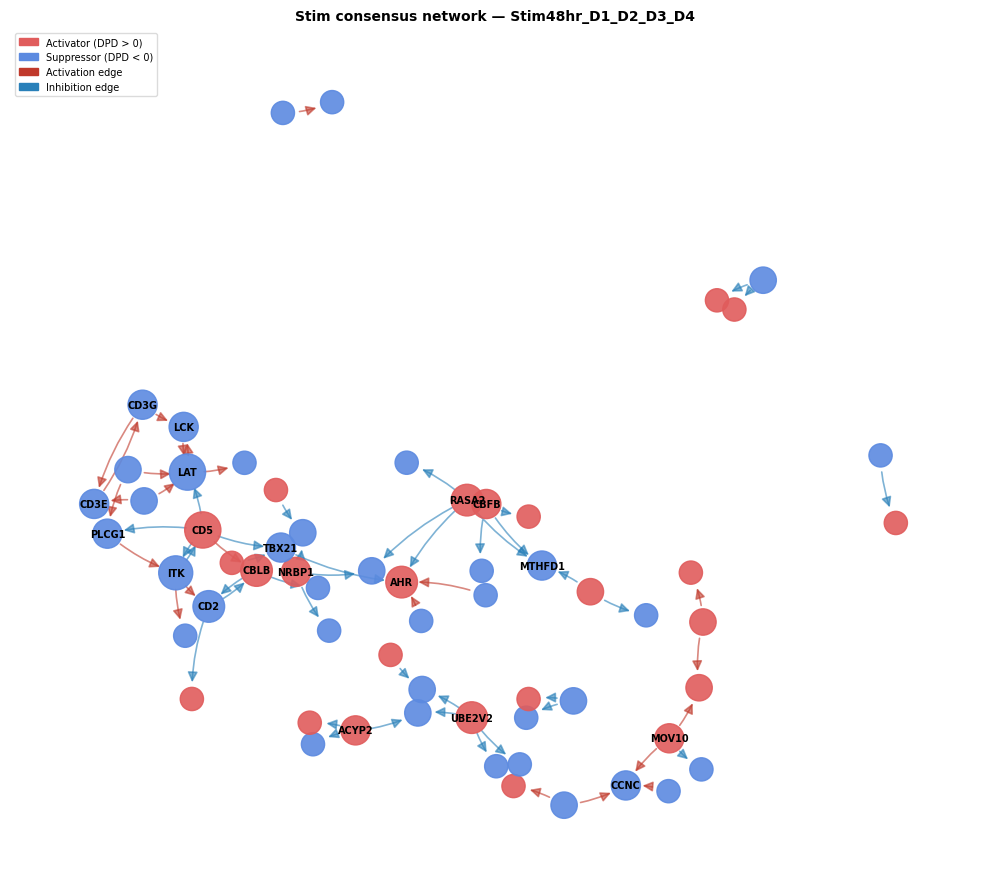

Saved: ../Results/Stim48hr/rols/network_viz_Stim48hr_D1_D2_D3_D4.png


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_network(edges_df, node_df, title, ax):
    if edges_df is None or edges_df.empty:
        ax.set_visible(False)
        return

    G = nx.DiGraph()
    genes_in_edges = set(edges_df['source']) | set(edges_df['target'])
    G.add_nodes_from(genes_in_edges)
    for _, row in edges_df.iterrows():
        G.add_edge(row['source'], row['target'],
                   edge_type=row['edge_type'],
                   weight=abs(row['rols_strength']))

    # Node attributes from node_df, restricted to genes in this network
    nd = node_df.set_index('gene')
    degree = dict(G.degree())
    node_colors = []
    node_sizes = []
    for g in G.nodes():
        role = nd.loc[g, 'role_stim'] if g in nd.index else 'suppressor'
        node_colors.append('#e05c5c' if role == 'activator' else '#5c8ae0')
        node_sizes.append(200 + degree.get(g, 0) * 80)

    # Edge colors
    edge_colors = ['#c0392b' if G.edges[e]['edge_type'] == 'activation' else '#2980b9'
                   for e in G.edges()]

    # Layout: spring for < 50 nodes, kamada_kawai otherwise
    if len(G.nodes()) < 50:
        pos = nx.spring_layout(G, seed=42, k=1.8)
    else:
        pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color=edge_colors, alpha=0.6, width=1.2,
                           arrows=True, arrowstyle='-|>', arrowsize=15,
                           connectionstyle='arc3,rad=0.1',
                           min_source_margin=12, min_target_margin=12)

    # Labels only for hubs
    hub_labels = {g: g for g in G.nodes() if degree.get(g, 0) >= 3}
    nx.draw_networkx_labels(G, pos, labels=hub_labels, ax=ax,
                            font_size=7, font_weight='bold')

    # Legend
    legend_elements = [
        mpatches.Patch(color='#e05c5c', label='Activator (DPD > 0)'),
        mpatches.Patch(color='#5c8ae0', label='Suppressor (DPD < 0)'),
        mpatches.Patch(color='#c0392b', label='Activation edge'),
        mpatches.Patch(color='#2980b9', label='Inhibition edge'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=0.7)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

n_axes = 1 if SKIP_BTLA else 2
fig, axes = plt.subplots(1, n_axes, figsize=(10 * n_axes, 9))
if n_axes == 1:
    axes = [axes]

plot_network(final_stim, node_df, f'Stim consensus network: {run_tag}', axes[0])
if not SKIP_BTLA:
    plot_network(final_btla, node_df, f'BTLA consensus network: {run_tag}', axes[1])

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, f'network_viz_{run_tag}.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


### 10. Save


In [22]:
# Strength-threshold edges from A_rols
if not edges_strength_rols.empty:
    edges_strength_rols.to_csv(os.path.join(OUT_DIR, f'edges_strength_rols_{run_tag}.csv'), index=False)
print('Saved: edges_strength_rols')

# Final consensus edges, CSV and Cytoscape tab-separated
if not final_stim.empty:
    final_stim.to_csv(os.path.join(OUT_DIR, f'edges_final_stim_{run_tag}.csv'), index=False)
    final_stim.to_csv(os.path.join(OUT_DIR, f'edges_final_stim_{run_tag}_cytoscape.txt'),
                      sep='\t', index=False)
if not SKIP_BTLA and not final_btla.empty:
    final_btla.to_csv(os.path.join(OUT_DIR, f'edges_final_btla_{run_tag}.csv'), index=False)
    final_btla.to_csv(os.path.join(OUT_DIR, f'edges_final_btla_{run_tag}_cytoscape.txt'),
                      sep='\t', index=False)
print('Saved: edges_final_stim' + ('' if SKIP_BTLA else ' and edges_final_btla'))

# Node table (also used by Notebook 5)
node_path = os.path.join(OUT_DIR, f'nodes_annotated_{run_tag}.csv')
node_df.to_csv(node_path, index=False)
print(f'Saved: {node_path}')

print(f'\nAll outputs saved to {OUT_DIR}/')

# STRING/TRRUST validation summary (percentile sweep) and checkpoint gene detail
validation_summary.to_csv(os.path.join(OUT_DIR, f'validation_string_trrust_{run_tag}.csv'), index=False)
print('Saved: validation_string_trrust')
if not checkpoint_detail.empty:
    checkpoint_detail.to_csv(os.path.join(OUT_DIR, f'validation_checkpoint_genes_{run_tag}.csv'), index=False)
    print('Saved: validation_checkpoint_genes')

# Recap table (full, ordered; notebook printed only top 30)
recap_table.to_csv(os.path.join(OUT_DIR, f'recap_table_{run_tag}.csv'), index=False)
print('Saved: recap_table')


Saved: edges_strength_rols
Saved: edges_final_stim
Saved: ../Results/Stim48hr/rols/nodes_annotated_Stim48hr_D1_D2_D3_D4.csv

All outputs saved to ../Results/Stim48hr/rols/
Saved: validation_string_trrust
Saved: recap_table
